In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import mne
import os
import time

participantsInfo = pd.read_table('./ds004504/participants.tsv')


#Getting all the participaants 
#note rename A-sub to a better name such as alzSub , also don't know if this part is necessary
A_sub = participantsInfo[participantsInfo["Group"] == "A"]["participant_id"].tolist()
C_sub = participantsInfo[participantsInfo["Group"] == "C"]["participant_id"].tolist()
D_sub = participantsInfo[participantsInfo["Group"] == "F"]["participant_id"].tolist()

freqBands = {
    "Delta": (0.5, 4),
    "Theta": (4, 8),
    "Alpha": (8, 12),
    "Beta": (12, 30),
}

#*******
def subPath(sub, derivatives=True):
    if(derivatives):
       path = f"ds004504/derivatives/{sub}/eeg/{sub}_task-eyesclosed_eeg.set"
    else:
       path = f"ds004504/{sub}/eeg/{sub}_task-eyesclosed_eeg.set"
    
    if not os.path.exists(path):
        raise FileNotFoundError(f'The path was not found for {sub}')

    return path

In [2]:
#I think menthod not here ,what is preload ? 
def processSub(sub, derivatives=True, method='welch', windowLength=3, stepSize=1.5):
    rawSub = mne.io.read_raw_eeglab(subPath(sub, derivatives), preload=True)
    stdFreq = rawSub.info['sfreq'] #standard frequency, it should be 500hz

    startTimes = np.arange(0, rawSub.times[-1] - windowLength, stepSize)

    events = np.array([
    [int(t * stdFreq), 0, 1] for t in startTimes  # MNE event format
    ]) 

    # * we may need to remove gaps from if derivatives is true
    epochs = mne.Epochs(rawSub, events, event_id=1, tmin=0, tmax=windowLength, baseline=None, detrend=1, preload=True, verbose=False)

    freqLow = freqBands['Delta'][0]
    freqHigh = freqBands['Beta'][1]

    psds = []

    # * can multiprocess this part if need be or make it a generator (with yeild)
    for idx in range(len(epochs)):
        epoch = epochs[idx]
        # epochPsd = epoch.compute_psd(fmin=freqLow, fmax=freqHigh, verbose=False)
        epochPsd = epoch.compute_psd(fmin=freqLow, fmax=freqHigh, method=method, verbose=False)
        psds.append(epochPsd)
    
    return psds

In [7]:
def processSub(sub, derivatives=True, method='welch', windowLength=3, stepSize=1.5):
    rawSub = mne.io.read_raw_eeglab(subPath(sub, derivatives), preload=True)
    stdFreq = rawSub.info['sfreq'] #standard frequency, it should be 500hz

    startTimes = np.arange(0, rawSub.times[-1] - windowLength, stepSize)

    events = np.array([
    [int(t * stdFreq), 0, 1] for t in startTimes  # MNE event format
    ]) 

    # * we may need to remove gaps from if derivatives is true
    epochs = mne.Epochs(rawSub, events, event_id=1, tmin=0, tmax=windowLength, baseline=None, detrend=1, preload=True, verbose=False)

    freqLow = freqBands['Delta'][0]
    freqHigh = freqBands['Beta'][1]

    # psds = []

    # * can multiprocess this part if need be or make it a generator (with yeild)
    for idx in range(len(epochs)):
        epoch = epochs[idx]
        # epochPsd = epoch.compute_psd(fmin=freqLow, fmax=freqHigh, verbose=False)
        epochPsd = epoch.compute_psd(fmin=freqLow, fmax=freqHigh, method=method, verbose=False)
        yield epochPsd 
 

In [6]:
    

# if __name__ == '__main__':
#     subPath(sub=A_sub[0])
#     subPath(sub=A_sub[0],  derivatives=False)
#     psds = processSub(A_sub[0])
#     start = time.time()
#     print(psds[0])
#     psds[0].plot()

start = time.time()
psds = processSub(A_sub[0])
start = time.time()
print(psds[0])
psds[0].plot()
print(time.time() - start)


<Power Spectrum (from Epochs, welch method) | 1 epochs × 19 channels × 89 freqs, 0.7-30.0 Hz>
Plotting power spectral density (dB=True).
0.10317277908325195


/Users/user/jupyter-venv/lib/python3.12/site-packages/mne/viz/utils.py:158: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


In [8]:
psd_gen = processSub(A_sub[0])
first_psd = next(psd_gen)

print(first_psd)

<Power Spectrum (from Epochs, welch method) | 1 epochs × 19 channels × 89 freqs, 0.7-30.0 Hz>


Plotting power spectral density (dB=True).


/Users/user/jupyter-venv/lib/python3.12/site-packages/mne/viz/utils.py:158: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


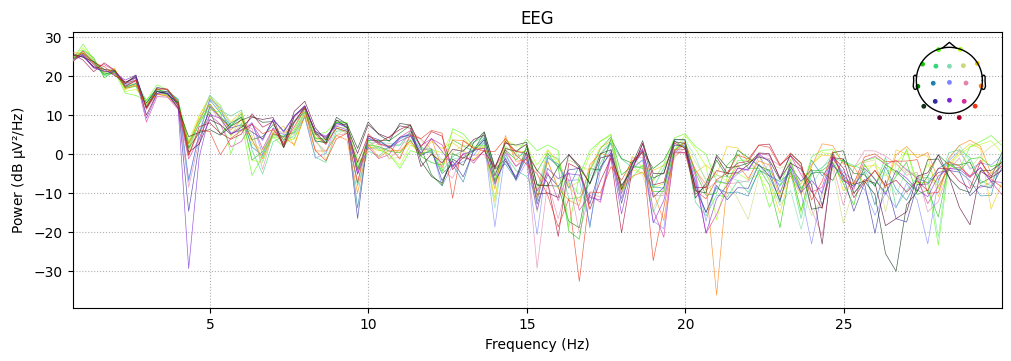

In [9]:
first_psd.plot()

Plotting power spectral density (dB=True).
Need more than one channel to make topography for eeg. Disabling interactivity.


/Users/user/jupyter-venv/lib/python3.12/site-packages/mne/viz/utils.py:158: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


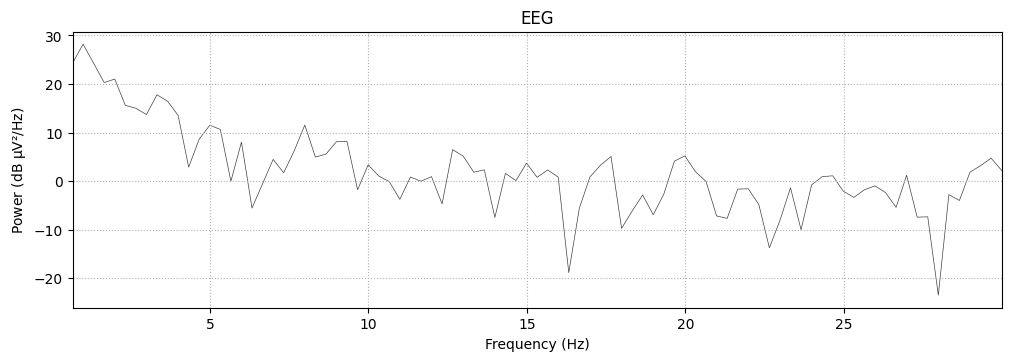

In [10]:
first_psd.plot(picks='Fp1')

In [14]:
print(first_psd.get_data())
print(first_psd.shape)

[[[2.68786335e-10 6.60766965e-10 2.67062184e-10 ... 2.08206894e-12
   2.96899051e-12 1.66135805e-12]
  [2.70292818e-10 5.36937235e-10 2.66918457e-10 ... 1.76331201e-12
   2.17517416e-12 1.10313256e-12]
  [2.90596871e-10 3.86530906e-10 2.38145258e-10 ... 2.05083995e-13
   1.51465784e-13 7.89388594e-13]
  ...
  [2.49551414e-10 4.36848251e-10 2.44200631e-10 ... 1.51837703e-13
   1.43442782e-13 8.41169100e-13]
  [2.49519831e-10 3.55848566e-10 1.98158239e-10 ... 5.77270930e-13
   5.17309239e-13 8.86549553e-13]
  [2.79065490e-10 3.33979377e-10 1.61102882e-10 ... 4.50629202e-13
   1.96367683e-13 1.85478893e-13]]]
(1, 19, 89)


In [26]:
def _psd_generator(epochs, compute_psd):
    for i in range(len(epochs)):
        yield compute_psd(epochs[i])

In [27]:
def processSub(sub, derivatives=True, method='welch', windowLength=3, stepSize=1.5, mode='generator', n_jobs=1):
    raw = mne.io.read_raw_eeglab(subPath(sub, derivatives), preload=True)
    sfreq = raw.info['sfreq']
    ch_names = raw.info['ch_names']

    start_times = np.arange(0, raw.times[-1] - windowLength, stepSize)
    events = np.array([[int(t * sfreq), 0, 1] for t in start_times])
    
    epochs = mne.Epochs(
        raw, events, event_id=1, tmin=0, tmax=windowLength,
        baseline=None, detrend=1, preload=True, verbose=False
    )

    freqLow = freqBands['Delta'][0]
    freqHigh = freqBands['Beta'][1]

    def compute_psd(epoch):
        return epoch.compute_psd(fmin=freqLow, fmax=freqHigh, method=method, verbose=False)

    if mode == 'generator':
        return _psd_generator(epochs, compute_psd)

    elif mode == 'sequential':
        return [compute_psd(epochs[i]) for i in range(len(epochs))]

    elif mode == 'parallel':
        return Parallel(n_jobs=n_jobs)(
            delayed(compute_psd)(epochs[i]) for i in range(len(epochs))
        )

    else:
        raise ValueError(f"Invalid mode '{mode}'. Choose from 'generator', 'sequential', or 'parallel'.")


In [29]:
start = time.time()
# Generator mode
for psd in processSub(A_sub[0], mode='generator'):
    # print(psd.get_data.shape)
    pass
print(time.time()-start)

start = time.time()
# Sequential
psds = processSub(A_sub[0], mode='sequential')
# print(psds[0].get_data().shape)
print(time.time()-start)

start = time.time()
# Parallel
psds_parallel = processSub(A_sub[0], mode='parallel', n_jobs=-1)
# print(psds_parallel)
print(time.time()-start)


15.564025163650513
16.114511251449585
18.59877300262451


In [30]:
start = time.time()
# Parallel
psds_parallel = processSub(A_sub[0], mode='parallel', n_jobs=4)
# print(psds_parallel)
print(time.time()-start)

19.33035111427307
